In [1]:
company_list = [
        'Accenture', 'Adobe', 'Cisco', 'Citi', 'DHL Express', 'Exxon Mobil', 'FedEx', 
        'General Electric', 'HSBC', 'Huawei', 'IBM', 'Intel', 'J.P. Morgan', 
        'Microsoft', 'Oracle', 'Salesforce', 'SAP', 'Shell', 'UPS', 'Wells Fargo'
    ]
non_biz_labels = ["Thought Leadership", "ESG & Purpose", "Employer Branding", "Public Relations & Lifestyle", "Macro/Crisis Response"]
label_list = ["Health & Public Service", "Products", "Financial Services", 
              "Digital Media", "Digital Marketing", "Digital Experience", "Print and Publishing",
              #"Product", "Service",
              "CITICORP", "Global Consumer Banking", "Personal Banking and Wealth Management",
              #"eCommerce Solutions", "Express",
              "Upstream", "Downstream", "Chemical Products",
              "FedEx Services segment", "FedEx Express segment", "FedEx Ground segment",
              "Aviation", "Healthcare", "Renewable Energy", "Transportation",
              "CMB", "RBWM", "Global Banking and Markets", 
              "Enterprise Business", "Carrier Business", "ICT Infrastructure Business", "Cloud Computing",
              "Software", "Cognitive Solutions", "Global Business Services", "Global Technology Services",
              "PC Client Group", "Client Computing Group", "Internet of Things Group", "Data Center Group",
              #"Corporate & Investment Bank", "Asset & Wealth Management", 
              "Windows PC operating systems", "Office products and cloud services", "Gaming",
              #"Cloud and license", "Hardware",
              "Subscription and support", "Professional services and other",
              #"Cloud and software", "Services", 
              #"Upstream", "Downstream",
              #"U.S. Domestic Package", "Supply Chain & Freight", "International Package",
              #"Community Banking", "Wealth, Brokerage and Retirement", "Wholesale Banking"
              ]
label_mapping = {"USPB": "U.S. Personal Banking",
                 "eCommerce": "eCommerce Solutions",
                 "Chemical": "Chemical Products",
                 "HealthCare": "Healthcare",
                 "GB&M": "Global Banking and Markets",
                 "GBM": "Global Banking and Markets",
                 "Carrier Network Business": "Carrier Business",
                 "Carrier Network": "Carrier Business",
                 "ICT Infrastructure": "ICT Infrastructure Business",
                 "Client Computing Group (CCG)": "Client Computing Group",
                 "Internet of Things Group (IOTG)": "Internet of Things Group",
                 "Data Center Group (DCG) ": "Data Center Group",
                 "Internet of Things": "Internet of Things Group",
                 "Asset Management": "Asset & Wealth Management",
                 "Windows PC operating system": "Windows PC operating systems"
                 }

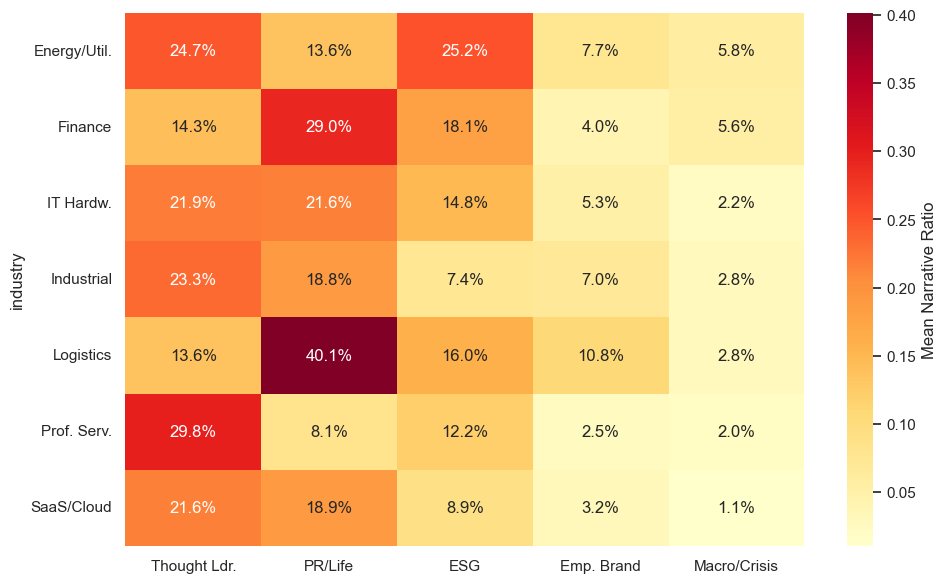

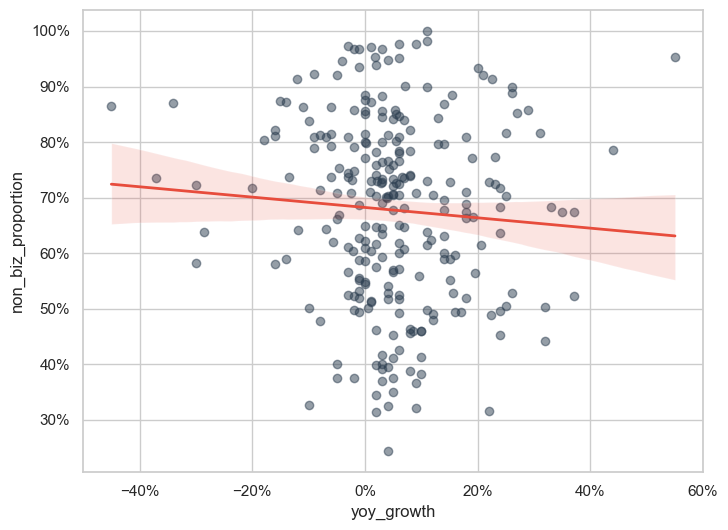

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Data load
csv_path = r"data/non-biz_yoy_growth.csv"
df = pd.read_csv(csv_path)

# 2. Industry abbreviation mapping
industry_map = {
    'Professional Services & Consulting': 'Prof. Serv.',
    'IT Infrastructure & Hardware': 'IT Hardw.',
    'Software & Cloud Services': 'SaaS/Cloud',
    'Logistics & Transportation': 'Logistics',
    'Industrial & Manufacturing': 'Industrial',
    'Energy & Utilities': 'Energy/Util.',
    'Financial Services': 'Finance'
}

category_map = {
    'Thought Leadership': 'Thought Ldr.',
    'Public Relations & Lifestyle': 'PR/Life',
    'ESG & Purpose': 'ESG',
    'Employer Branding': 'Emp. Brand',
    'Macro/Crisis Response': 'Macro/Crisis'
}

# 3. Data clearning
def clean_pct(val):
    if pd.isna(val): return 0.0
    val = str(val).replace('%', '').strip()
    try:
        return float(val) / 100.0
    except ValueError:
        return 0.0

df['yoy_growth'] = df['total_yoy_growth'].apply(clean_pct)
df['industry'] = df['industry_type'].map(industry_map)

# Calculate the total of non-business narratives
orig_non_biz_cols = list(category_map.keys())
df['non_biz_proportion'] = df[orig_non_biz_cols].sum(axis=1)

df_renamed = df.rename(columns=category_map)
new_non_biz_cols = list(category_map.values())

sns.set_theme(style="whitegrid")

# --- Industry Buffer Strength Heat Map ---
# Select the samples with low growth rates (≤5%)
df_low = df_renamed[df_renamed['yoy_growth'] <= 0.05]
heatmap_data = df_low.groupby('industry')[new_non_biz_cols].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".1%", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Mean Narrative Ratio'}
)
#plt.title('Industry Buffering Intensity during Downturns', fontsize=14, fontweight='bold')
#plt.ylabel('Industry (Abbr.)', fontsize=12)
#plt.xlabel('Narrative Categories (Abbr.)', fontsize=12)
plt.tight_layout()
plt.savefig('buffering_industry_heatmap.png', dpi=1000)

plt.figure(figsize=(8, 6))
ax1 = sns.regplot(data=df, x='yoy_growth', y='non_biz_proportion', 
                  scatter_kws={'alpha':0.5, 'color':'#2c3e50'}, 
                  line_kws={'color':'#e74c3c', 'lw':2})
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
#plt.title('Revenue Growth vs. Non-Business Narratives', fontweight='bold')
plt.savefig('buffering_scatter.png', dpi=1000)